# 03 - Full Training Pipeline

**Goal:** Run the long project workflow that produces final training artifacts.

**What you will learn:** How baseline, shaped, and curriculum PPO are trained, plotted, exported, and optionally evaluated.

**Inputs:** A working `soccertwos` environment and successful smoke notebook run.

**Outputs:** Ray checkpoints, learning-curve plots, exported agent folders/zips, optional eval outputs.

**Success criteria:** Required stages finish or fail with clear messages, and exportable checkpoints are recorded.

In [1]:
from pathlib import Path
import importlib
import os
import sys

PROJECT_MARKER = Path("soccer_twos_project") / "notebook_tools.py"


def _running_in_colab():
    if "google.colab" in sys.modules:
        return True
    if os.environ.get("COLAB_RELEASE_TAG") or os.environ.get("COLAB_GPU"):
        return True
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


def _candidate_project_roots():
    seen = set()

    def add(path):
        path = Path(path).expanduser()
        key = str(path)
        if key not in seen:
            seen.add(key)
            yield path

    for env_name in ("SOCCER_TWOS_PROJECT_ROOT", "PROJECT_ROOT"):
        value = os.environ.get(env_name)
        if value:
            yield from add(value)

    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        yield from add(base)
        yield from add(base / "soccer-twos-starter")
        yield from add(base / "project" / "soccer-twos-starter")

    if sys.platform == "darwin":
        yield from add(
            Path.home()
            / "all_data"
            / "Georgia Tech"
            / "Course Content"
            / "CS 8803- DRL"
            / "project"
            / "soccer-twos-starter"
        )

    if _running_in_colab():
        try:
            from google.colab import drive  # type: ignore
            if not Path("/content/drive/MyDrive").exists():
                drive.mount("/content/drive")
        except Exception:
            pass
        for drive_root in (Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives"), Path("/content")):
            for relative in (
                Path("CS 8803- DRL") / "project" / "soccer-twos-starter",
                Path("project") / "soccer-twos-starter",
                Path("soccer-twos-starter"),
                Path("Colab Notebooks") / "soccer-twos-starter",
            ):
                yield from add(drive_root / relative)


def _find_project_root():
    for candidate in _candidate_project_roots():
        if (candidate / PROJECT_MARKER).exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find soccer_twos_project/notebook_tools.py. "
        "Open this notebook from the project root/notebooks folder, or set SOCCER_TWOS_PROJECT_ROOT."
    )


PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for _module_name in list(sys.modules):
    if _module_name == "soccer_twos_project" or _module_name.startswith("soccer_twos_project."):
        del sys.modules[_module_name]

importlib.invalidate_caches()
from IPython.display import Markdown, display
from soccer_twos_project.notebook_tools import *

ctx = setup_project()
show_hardware()

Runtime: linux
Project root: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter
Artifact root: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos
Python: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python
soccer_twos: /coc/scratch/dgarg/miniconda3/envs/soccertwos/lib/python3.8/site-packages/soccer_twos/__init__.py
ray: 1.13.0
torch: 1.8.1+cu111
python: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python
{
  "cpu_count": 128,
  "gpu_name": "NVIDIA A40",
  "mlx_available": false,
  "ram_gb": 503.69,
  "torch_cuda_available": true,
  "torch_cuda_device_count": 8,
  "torch_cuda_device_names": [
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40"
  ],
  "torch_cuda_runtime_probe_device": "NVIDIA A40",
  "torch_cuda_runtime_probe_error": "",
  "torch_cuda_runtime_ready": true,
  "torch_cuda_version": "11.1",
  "torch_mps_available": false,
  "

## Configuration

Fill in author metadata before exporting. Leave `FULL_TIMESTEPS = None` to use the selected hardware profile default.

In [2]:
AUTHOR = "Vedaang Chopra"
EMAIL = "vedaangchopra@gatech.edu"

PROFILE_NAME    = "a40_full"      # proven on A40 cluster
FULL_TIMESTEPS  = 30_000_000      # V3 extended run: 20 Million timesteps total!

# ── v3: only re-run curriculum, skip stages that are already done ──
RUN_BASELINE    = False   # already done
RUN_SHAPED      = False   # already done
RUN_CURRICULUM  = True    # continues as ppo_curriculum_v3
RUN_SELFPLAY    = False   # skip
RUN_EXPORTS     = True
RUN_IMITATION   = True
RUN_QUICK_EVAL  = True
RUN_TENSORBOARD = True

# Use a fresh port block well above the old run's range
import os
os.environ.setdefault("SOCCER_TWOS_BASE_PORT", "52000")

from soccer_twos_project.config import cuda_training_report, profile_dict, select_profile
selected_profile = select_profile(PROFILE_NAME, smoke=False)
print_json({"selected_profile": profile_dict(selected_profile), "cuda_auto_detection": cuda_training_report(selected_profile)})

{
  "cuda_auto_detection": {
    "cuda_required_by_profile": true,
    "cuda_visible_devices": "",
    "profile": "a40_full",
    "profile_num_gpus": 1,
    "ready_for_cuda_training": true,
    "torch_cuda_available": true,
    "torch_cuda_device_count": 8,
    "torch_cuda_device_names": [
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40",
      "NVIDIA A40"
    ],
    "torch_cuda_runtime_probe_device": "NVIDIA A40",
    "torch_cuda_runtime_probe_error": "",
    "torch_cuda_runtime_ready": true,
    "torch_cuda_version": "11.1",
    "torch_version": "1.8.1+cu111"
  },
  "selected_profile": {
    "checkpoint_freq": 10,
    "name": "a40_full",
    "num_envs_per_worker": 1,
    "num_gpus": 1,
    "num_workers": 40,
    "rollout_fragment_length": 2000,
    "time_total_s": null,
    "timesteps_total": 50000000,
    "train_batch_size": 80000
  }
}


## Optional TensorBoard

Start this before long training if you want live curves.

In [3]:
print("TensorBoard logdir:", ctx.dirs["checkpoints"])
if RUN_TENSORBOARD:
    tensorboard_proc = launch_tensorboard(ctx, port=6006)
else:
    print("TensorBoard not launched. Set RUN_TENSORBOARD=True if needed.")

TensorBoard logdir: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints
TensorBoard command: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python -m tensorboard.main --logdir /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints --port 6006 --reload_interval 10
Open: http://localhost:6006
PID: 1418608


## Train Required PPO Agents

The report should compare these three learning curves.

2026-04-23 20:35:33,711	INFO tune.py:747 -- Total run time: 8788.31 seconds (8786.66 seconds for the tuning loop).


Best trial: PPO_Soccer_0b1b1_00000
Best checkpoint: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum_v3/PPO_Soccer_0b1b1_00000_0_2026-04-23_18-09-05/checkpoint_000360/checkpoint-360
Wrote run metadata: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum_v3/run_metadata.json
Returned checkpoint: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum_v3/PPO_Soccer_0b1b1_00000_0_2026-04-23_18-09-05/checkpoint_000360/checkpoint-360

Inline progress summary for ppo_curriculum_v3
Latest progress file: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum_v3/PPO_Soccer_0b1b1_00000_0_2026-04-23_18-09-05/progress.csv


,training_iteration,timesteps_total,episodes_total,episode_reward_mean,episode_reward_min,episode_reward_max,episode_len_mean,time_total_s
361,384,29288353,1676103,1.969653,1.4296,1.9968,15.367698,9104.986170
362,385,29368720,1681341,1.968969,-2.0000,1.9972,15.343070,9125.579229
363,386,29449038,1686596,1.969840,1.6200,1.9968,15.284110,9145.745066
364,387,29529518,1691785,1.969373,0.0000,1.9964,15.509732,9165.896637
365,388,29609913,1697051,1.969123,-2.0000,1.9964,15.266806,9186.558903
366,389,29690357,1702247,1.968674,-2.0000,1.9960,15.481909,9209.031005
367,390,29770647,1707553,1.969399,-2.0000,1.9964,15.131926,9235.232057
368,391,29850916,1712913,1.970451,1.7264,1.9964,14.975560,9261.178206
369,392,29931301,1718212,1.969351,-2.0000,1.9960,15.169843,9285.017092
370,393,30011592,1723482,1.969184,-2.0000,1.9964,15.235484,9309.719522


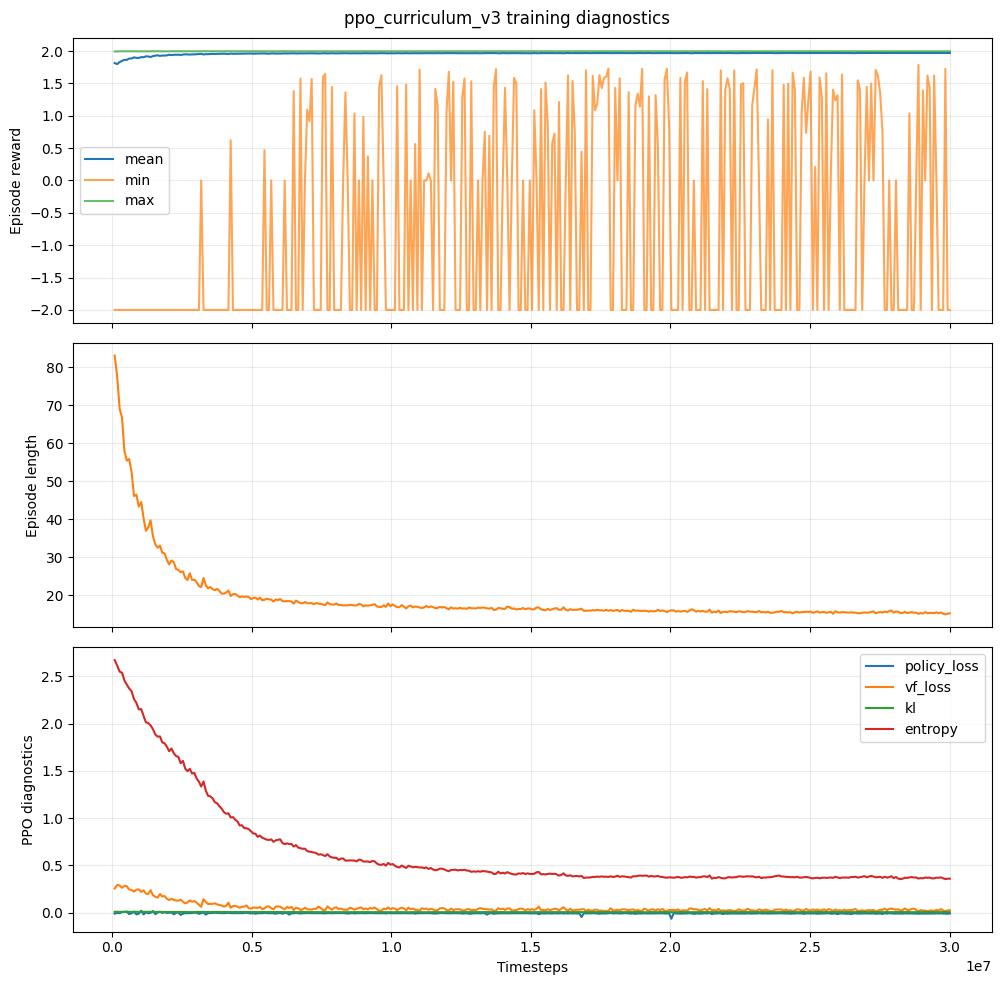

{'ppo_curriculum_v3': '/coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum_v3/PPO_Soccer_0b1b1_00000_0_2026-04-23_18-09-05/checkpoint_000360/checkpoint-360'}

In [4]:
# We will resume from the original successful V1 checkpoint at 2M steps.
CURRICULUM_CHECKPOINT = (
    "artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_curriculum/PPO_Soccer_8ce04_00000_0_2026-04-23_09-08-41/checkpoint_000022/checkpoint-22"
)

trained_checkpoints = {}

if RUN_CURRICULUM:
    try:
        trained_checkpoints["ppo_curriculum_v3"] = run_training(
            ctx,
            "ppo_curriculum_v3",           # new stage → new experiment folder
            profile_name=PROFILE_NAME,
            timesteps=FULL_TIMESTEPS,
            restore=CURRICULUM_CHECKPOINT, # resume from iter 22
            verbose=1,
        )
        print("\nInline progress summary for ppo_curriculum_v3")
        show_training_snapshot(
            ctx,
            "ppo_curriculum_v3",
            rows=10,
            title="ppo_curriculum_v3 training diagnostics",
        )
    except Exception as exc:
        print("ppo_curriculum_v3 failed:", type(exc).__name__, exc)
else:
    print("ppo_curriculum skipped by configuration.")

trained_checkpoints

## Optional Self-Play Fallback

Run only if curriculum does not produce a useful policy or you need another comparison.

In [5]:
if RUN_SELFPLAY:
    try:
        trained_checkpoints["ppo_selfplay"] = run_training(
            ctx,
            "ppo_selfplay",
            profile_name=PROFILE_NAME,
            timesteps=FULL_TIMESTEPS,
            verbose=1,
        )
        print("\nInline progress summary for ppo_selfplay")
        show_training_snapshot(
            ctx,
            "ppo_selfplay",
            rows=10,
            title="ppo_selfplay training diagnostics",
        )
    except Exception as exc:
        print("ppo_selfplay failed:", type(exc).__name__, exc)
else:
    print("Self-play skipped. Keep this off until the required PPO stages are working.")

Self-play skipped. Keep this off until the required PPO stages are working.


## Plot Learning Curves

This section shows inline comparison plots in the notebook and also writes PNG artifacts to the plots folder. Rerun it after any training stage to refresh the view.

Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_baseline__PPO_Soccer_2c827_00000_0_2026-04-23_08-51-41.png
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_baseline__PPO_Soccer_79595_00000_0_2026-04-23_08-32-21.png
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_baseline__PPO_Soccer_87dbd_00000_0_2026-04-23_08-18-26.png
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_curriculum__PPO_Soccer_8ce04_00000_0_2026-04-23_09-08-41.png
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_curriculum_v2__PPO_Soccer_dca3b_00000_0_2026-04-23_16-13-15.png
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots/soccer_ppo_curriculum_v3__PPO_S

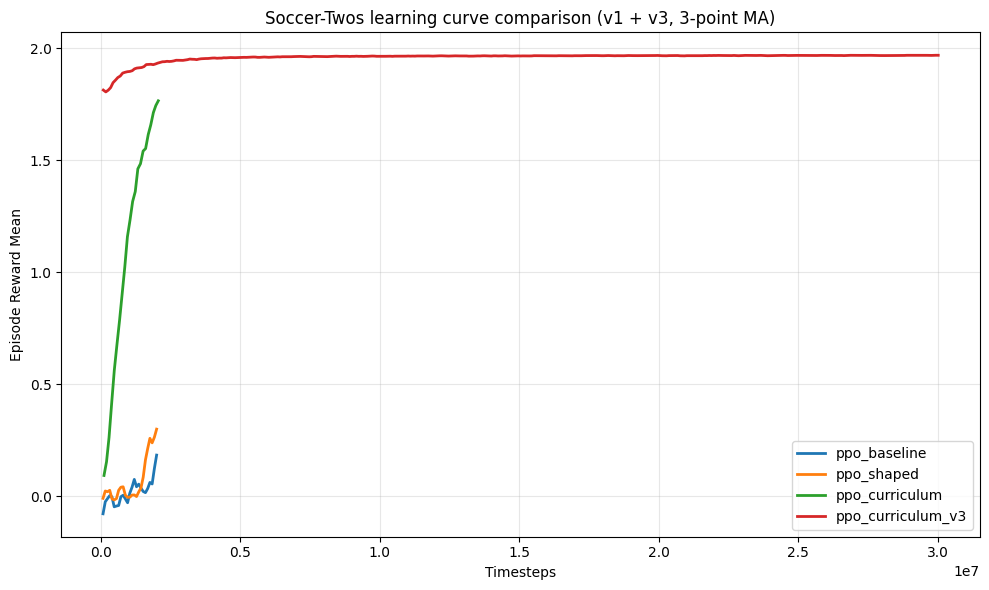

,stage,episode_reward_mean,training_iteration,timesteps_total,episodes_total,episode_reward_max,episode_len_mean,time_total_s
0,ppo_baseline,0.239864,25,2000000,2100,1.9120,832.280000,492.249723
1,ppo_shaped,0.403566,25,2000000,2177,1.9484,676.705882,471.787553
2,ppo_curriculum,1.786909,22,2060547,8691,1.9964,92.847193,591.159465
3,ppo_curriculum_v3,1.969184,393,30011592,1723482,1.9964,15.235484,9309.719522


Saved plot directory: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/plots


In [6]:
from soccer_twos_project.plotting import plot_results

try:
    plot_results(SimpleNamespace(
        artifact_root=str(ctx.artifact_root),
        ray_results=str(ctx.dirs["checkpoints"]),
        output_dir=str(ctx.dirs["plots"]),
        filter=None,
    ))
except Exception as exc:
    print("Plot generation skipped:", type(exc).__name__, exc)

comparison_stages = [
    "ppo_baseline",
    "ppo_shaped",
    "ppo_curriculum",
    "ppo_curriculum_v3"
]
comparison_table = compare_training_progress(
    ctx,
    stages=comparison_stages,
    smoothing_window=3,
    title="Soccer-Twos learning curve comparison (v1 + v3, 3-point MA)",
)
if comparison_table.empty:
    print("No inline comparison plot available yet.")
else:
    display(comparison_table)
    print("Saved plot directory:", ctx.dirs["plots"])

## Export Standalone Agents

Export converts RLlib checkpoints into lightweight `AgentInterface` packages. These are what evaluation and submission use.

In [7]:
from soccer_twos_project.exporting import export_checkpoint

EXPORT_SPECS = {
    "ppo_baseline": ("soccer_ppo_baseline", "PPO baseline trained against a simple opponent."),
    "ppo_shaped":   ("soccer_ppo_shaped",   "PPO trained with clipped distance-based reward shaping."),
    "ppo_curriculum_v3": (
        "soccer_ppo_curriculum_v3",
        "PPO curriculum (V3): 20M timesteps.",
    ),
}

exported_agents = []
if RUN_EXPORTS:
    for stage, (agent_name, description) in EXPORT_SPECS.items():
        try:
            checkpoint = best_checkpoint(ctx, stage)
        except Exception as exc:
            print(stage, "export skipped; no checkpoint:", type(exc).__name__, exc)
            continue
        try:
            export_checkpoint(SimpleNamespace(
                checkpoint=checkpoint,
                stage=stage,
                policy_id="default_policy",
                profile="cpu_debug",
                artifact_root=str(ctx.artifact_root),
                output_dir=None,
                agent_name=agent_name,
                author=AUTHOR,
                email=EMAIL,
                description=description,
                no_zip=False,
                clean=True,
            ))
            exported_agents.append(agent_name)
        except Exception as exc:
            print(stage, "export failed:", type(exc).__name__, exc)
else:
    print("Exports skipped by RUN_EXPORTS=False.")

exported_agents

2026-04-23 20:35:46,004	INFO ppo.py:414 -- In multi-agent mode, policies will be optimized sequentially by the multi-GPU optimizer. Consider setting simple_optimizer=True if this doesn't work for you.


[INFO] Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


INFO:mlagents_envs.environment:Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


[INFO] Connected new brain: SoccerTwos?team=1


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=1


...

INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=1


[INFO] Connected new brain: SoccerTwos?team=0


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=0
2026-04-23 20:36:02,940	WARNING env.py:135 -- Your env doesn't have a .spec.max_episode_steps attribute. This is fine if you have set 'horizon' in your config dictionary, or `soft_horizon`. However, if you haven't, 'horizon' will default to infinity, and your environment will not be reset.
2026-04-23 20:36:02,960	INFO ppo_tf_policy.py:382 -- `vf_share_layers=True` in your model. Therefore, remember to tune the value of `vf_loss_coeff`!
2026-04-23 20:36:02,965	INFO torch_policy.py:190 -- TorchPolicy (worker=local) running on CPU.
2026-04-23 20:36:02,972	INFO rollout_worker.py:1793 -- Built policy map: {}
2026-04-23 20:36:02,973	INFO rollout_worker.py:1794 -- Built preprocessor map: {'default_policy': <ray.rllib.models.preprocessors.NoPreprocessor object at 0x7e50306d7160>}
2026-04-23 20:36:02,974	INFO rollout_worker.py:670 -- Built filter map: {'default_policy': <ray.rllib.utils.filter.NoFilter object at 0x7e50306d73d

Wrote package: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/submissions/soccer_ppo_curriculum_v3
Wrote zip: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/submissions/soccer_ppo_curriculum_v3.zip


['soccer_ppo_baseline', 'soccer_ppo_shaped', 'soccer_ppo_curriculum_v3']

## Optional Imitation Agent

Use imitation only after exporting a strong expert. The default expert is the curriculum PPO package.

In [8]:
RUN_IMITATION = True
if RUN_IMITATION:
    from soccer_twos_project.imitation import collect_dataset, train_bc

    EXPERT_MODULE = "soccer_ppo_curriculum"
    DATASET_PATH = ctx.dirs["datasets"] / "bc_expert_dataset.npz"
    collect_dataset(SimpleNamespace(
        expert_module=EXPERT_MODULE,
        samples=10_000,
        output=str(DATASET_PATH),
        base_port=None,
        artifact_root=str(ctx.artifact_root),
    ))
    train_bc(SimpleNamespace(
        dataset=str(DATASET_PATH),
        agent_name="soccer_bc_imitation",
        author=AUTHOR,
        email=EMAIL,
        description="Behavior cloning Soccer-Twos agent trained from an exported expert.",
        hidden_layers="256,256",
        epochs=10,
        batch_size=256,
        lr=1e-3,
        val_fraction=0.1,
        seed=0,
        output_dir=None,
        artifact_root=str(ctx.artifact_root),
        no_zip=False,
    ))
else:
    print("Imitation skipped. Keep RUN_IMITATION=False until a strong expert package exists.")

[INFO] Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


INFO:mlagents_envs.environment:Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


[INFO] Connected new brain: SoccerTwos?team=1


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=1


[INFO] Connected new brain: SoccerTwos?team=0


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=0


Wrote dataset: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/datasets/bc_expert_dataset.npz
Samples: 10000 Episodes: 62
epoch=1 train_loss=2.2021 val_loss=1.4129 val_acc=0.589
epoch=2 train_loss=1.1486 val_loss=0.8592 val_acc=0.710
epoch=3 train_loss=0.7602 val_loss=0.6134 val_acc=0.786
epoch=4 train_loss=0.5663 val_loss=0.4733 val_acc=0.831
epoch=5 train_loss=0.4632 val_loss=0.4222 val_acc=0.852
epoch=6 train_loss=0.3936 val_loss=0.3920 val_acc=0.845
epoch=7 train_loss=0.3545 val_loss=0.4021 val_acc=0.851
epoch=8 train_loss=0.3281 val_loss=0.3639 val_acc=0.860
epoch=9 train_loss=0.2931 val_loss=0.3776 val_acc=0.854
epoch=10 train_loss=0.2756 val_loss=0.3367 val_acc=0.869
Wrote imitation package: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/submissions/soccer_bc_imitation
Wrote zip: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/submissions/soccer_bc_imita

## Quick Evaluation Hooks

Use 5 episodes to catch import/action bugs. Save larger report numbers for the submission notebook.

In [9]:
if RUN_QUICK_EVAL:
    from soccer_twos_project.evaluation import evaluate, safe_label, write_outputs

    def evaluate_pair(agent1, agent2, episodes=10):
        rows, summary = evaluate(agent1, agent2, episodes=episodes, base_port=None)
        write_outputs(rows, summary, ctx.dirs["evals"], safe_label(agent1, agent2))
        return summary

    display(pd.DataFrame([
        evaluate_pair("soccer_ppo_curriculum",    "soccer_ppo_curriculum_v3", episodes=10),
        evaluate_pair("soccer_ppo_baseline",      "soccer_ppo_curriculum_v3", episodes=10),
    ]))
else:
    print("Quick eval skipped. Set RUN_QUICK_EVAL=True after exports exist.")

[INFO] Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


INFO:mlagents_envs.environment:Connected to Unity environment with package version 2.1.0-exp.1 and communication version 1.5.0


[INFO] Connected new brain: SoccerTwos?team=1


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=1


[INFO] Connected new brain: SoccerTwos?team=0


...

INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=1


[INFO] Connected new brain: SoccerTwos?team=0


INFO:mlagents_envs.environment:Connected new brain: SoccerTwos?team=0


Episode 1/10 complete
Episode 2/10 complete
Episode 3/10 complete
Episode 4/10 complete
Episode 5/10 complete
Episode 6/10 complete
Episode 7/10 complete
Episode 8/10 complete
Episode 9/10 complete
Episode 10/10 complete
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/evals/soccer_ppo_baseline_vs_soccer_ppo_curriculum_v3_episodes.csv
Wrote /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/evals/soccer_ppo_baseline_vs_soccer_ppo_curriculum_v3_summary.json


,agent1,agent2,episodes,agent1_reward_mean,agent2_reward_mean,agent1_reward_min,agent1_reward_max,agent2_reward_min,agent2_reward_max,agent1_wins,agent1_losses,draws,agent1_win_rate,episode_len_mean
0,soccer_ppo_curriculum,soccer_ppo_curriculum_v3,10,-0.42576,0.34072,-2.0,1.9780,-2.0,1.9592,4,6,0,0.4,42.8
1,soccer_ppo_baseline,soccer_ppo_curriculum_v3,10,-1.20836,1.11404,-2.0,1.9744,-2.0,1.9744,2,8,0,0.2,47.3


## Key Takeaways

The full pipeline trains the required PPO variants, plots their learning curves, and exports standalone packages. Optional methods stay behind explicit toggles.

## What To Run Next

Run `04_submission_and_report.ipynb` to validate packages, create the final zip, and gather report artifacts. Run `05_submission_smoke_test.ipynb` any time you want a fast end-to-end submission-path check.